# Explainability & Interpretability (XAI)

## Why XAI Matters in Medical AI
A model that achieves 95% AUC is clinically useless if dermatologists cannot trust its reasoning.  
This notebook applies three complementary explanation methods:

| Method | Type | What it shows |
|--------|------|---------------|
| **GradCAM** | Gradient × activation | Coarse class-discriminative heatmap |
| **GradCAM++** | Weighted gradient | Better handles multiple object instances |
| **Integrated Gradients** | Axiomatic attribution | Pixel-level attribution, theoretically sound |

## Expected Findings
- Melanoma: model should attend to irregular borders, asymmetry, colour variation
- BCC: pearly nodule, telangiectasia
- Nevi: typically uniform round lesions
- Hair artefacts should NOT dominate — validates our hair augmentation strategy

In [1]:
import sys
sys.path.insert(0, '..')
import os, torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import pandas as pd

from src.dataset  import build_dataloaders, CLASS_NAMES, build_image_path_map, get_transforms
from src.models   import build_model
from src.evaluate import (
    GradCAM, GradCAMPlusPlus, IntegratedGradients,
    visualise_explanations
)

os.makedirs('../results/xai', exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = '../dataset'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Best Model

In [2]:
model = build_model('efficientnet_b4', num_classes=7, pretrained=False)
ckpt  = torch.load('../checkpoints/efficientnet_b4_best.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE).eval()
print('Best EfficientNet-B4 loaded')
print(f'  Epoch: {ckpt["epoch"]}')
print(f'  Val Balanced Acc: {ckpt.get("val_balanced_acc", "N/A")}')

C:\Users\ghosh\AppData\Local\Temp\ipykernel_12820\327954639.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load('../checkpoints/efficientnet_b4_best.pth',

Best EfficientNet-B4 loaded
  Epoch: 40
  Val Balanced Acc: N/A


## 2. Select Target Layer for GradCAM

In [3]:
# For EfficientNet-B4, the last Conv block is: model.features[-1]
# Inspect model architecture
print('EfficientNet-B4 feature layers:')
for name, module in model.named_modules():
    if 'features' in name and len(name.split('.')) <= 3:
        print(f'  {name}: {type(module).__name__}')

# Target: last convolutional block before global average pool
target_layer = model.features[-1]
print(f'\nTarget layer: {target_layer.__class__.__name__}')

EfficientNet-B4 feature layers:
  features: Sequential
  features.0: Conv2dNormActivation
  features.0.0: Conv2d
  features.0.1: BatchNorm2d
  features.0.2: SiLU
  features.1: Sequential
  features.1.0: MBConv
  features.1.1: MBConv
  features.2: Sequential
  features.2.0: MBConv
  features.2.1: MBConv
  features.2.2: MBConv
  features.2.3: MBConv
  features.3: Sequential
  features.3.0: MBConv
  features.3.1: MBConv
  features.3.2: MBConv
  features.3.3: MBConv
  features.4: Sequential
  features.4.0: MBConv
  features.4.1: MBConv
  features.4.2: MBConv
  features.4.3: MBConv
  features.4.4: MBConv
  features.4.5: MBConv
  features.5: Sequential
  features.5.0: MBConv
  features.5.1: MBConv
  features.5.2: MBConv
  features.5.3: MBConv
  features.5.4: MBConv
  features.5.5: MBConv
  features.6: Sequential
  features.6.0: MBConv
  features.6.1: MBConv
  features.6.2: MBConv
  features.6.3: MBConv
  features.6.4: MBConv
  features.6.5: MBConv
  features.6.6: MBConv
  features.6.7: MBCon

## 3. Load Sample Images per Class

In [4]:
meta_df  = pd.read_csv(f'{DATA_ROOT}/HAM10000_metadata.csv')
path_map = build_image_path_map(DATA_ROOT)
transform = get_transforms('val', image_size=380)

# Pick 2 samples per class (14 total)
samples = []
for cls in CLASS_NAMES:
    rows = meta_df[meta_df['dx'] == cls].head(2)
    for _, row in rows.iterrows():
        img_id = row['image_id']
        path   = path_map.get(img_id)
        if path:
            pil_img    = Image.open(path).convert('RGB')
            tensor_img = transform(pil_img).unsqueeze(0).to(DEVICE)
            true_label = CLASS_NAMES.index(cls)
            samples.append({
                'image_id':   img_id,
                'class':      cls,
                'true_label': true_label,
                'pil_image':  pil_img,
                'tensor':     tensor_img,
            })

print(f'Loaded {len(samples)} sample images ({len(CLASS_NAMES)} classes × 2)')

Loaded 14 sample images (7 classes × 2)


## 4. GradCAM + GradCAM++

AttributeError: 'tuple' object has no attribute 'astype'

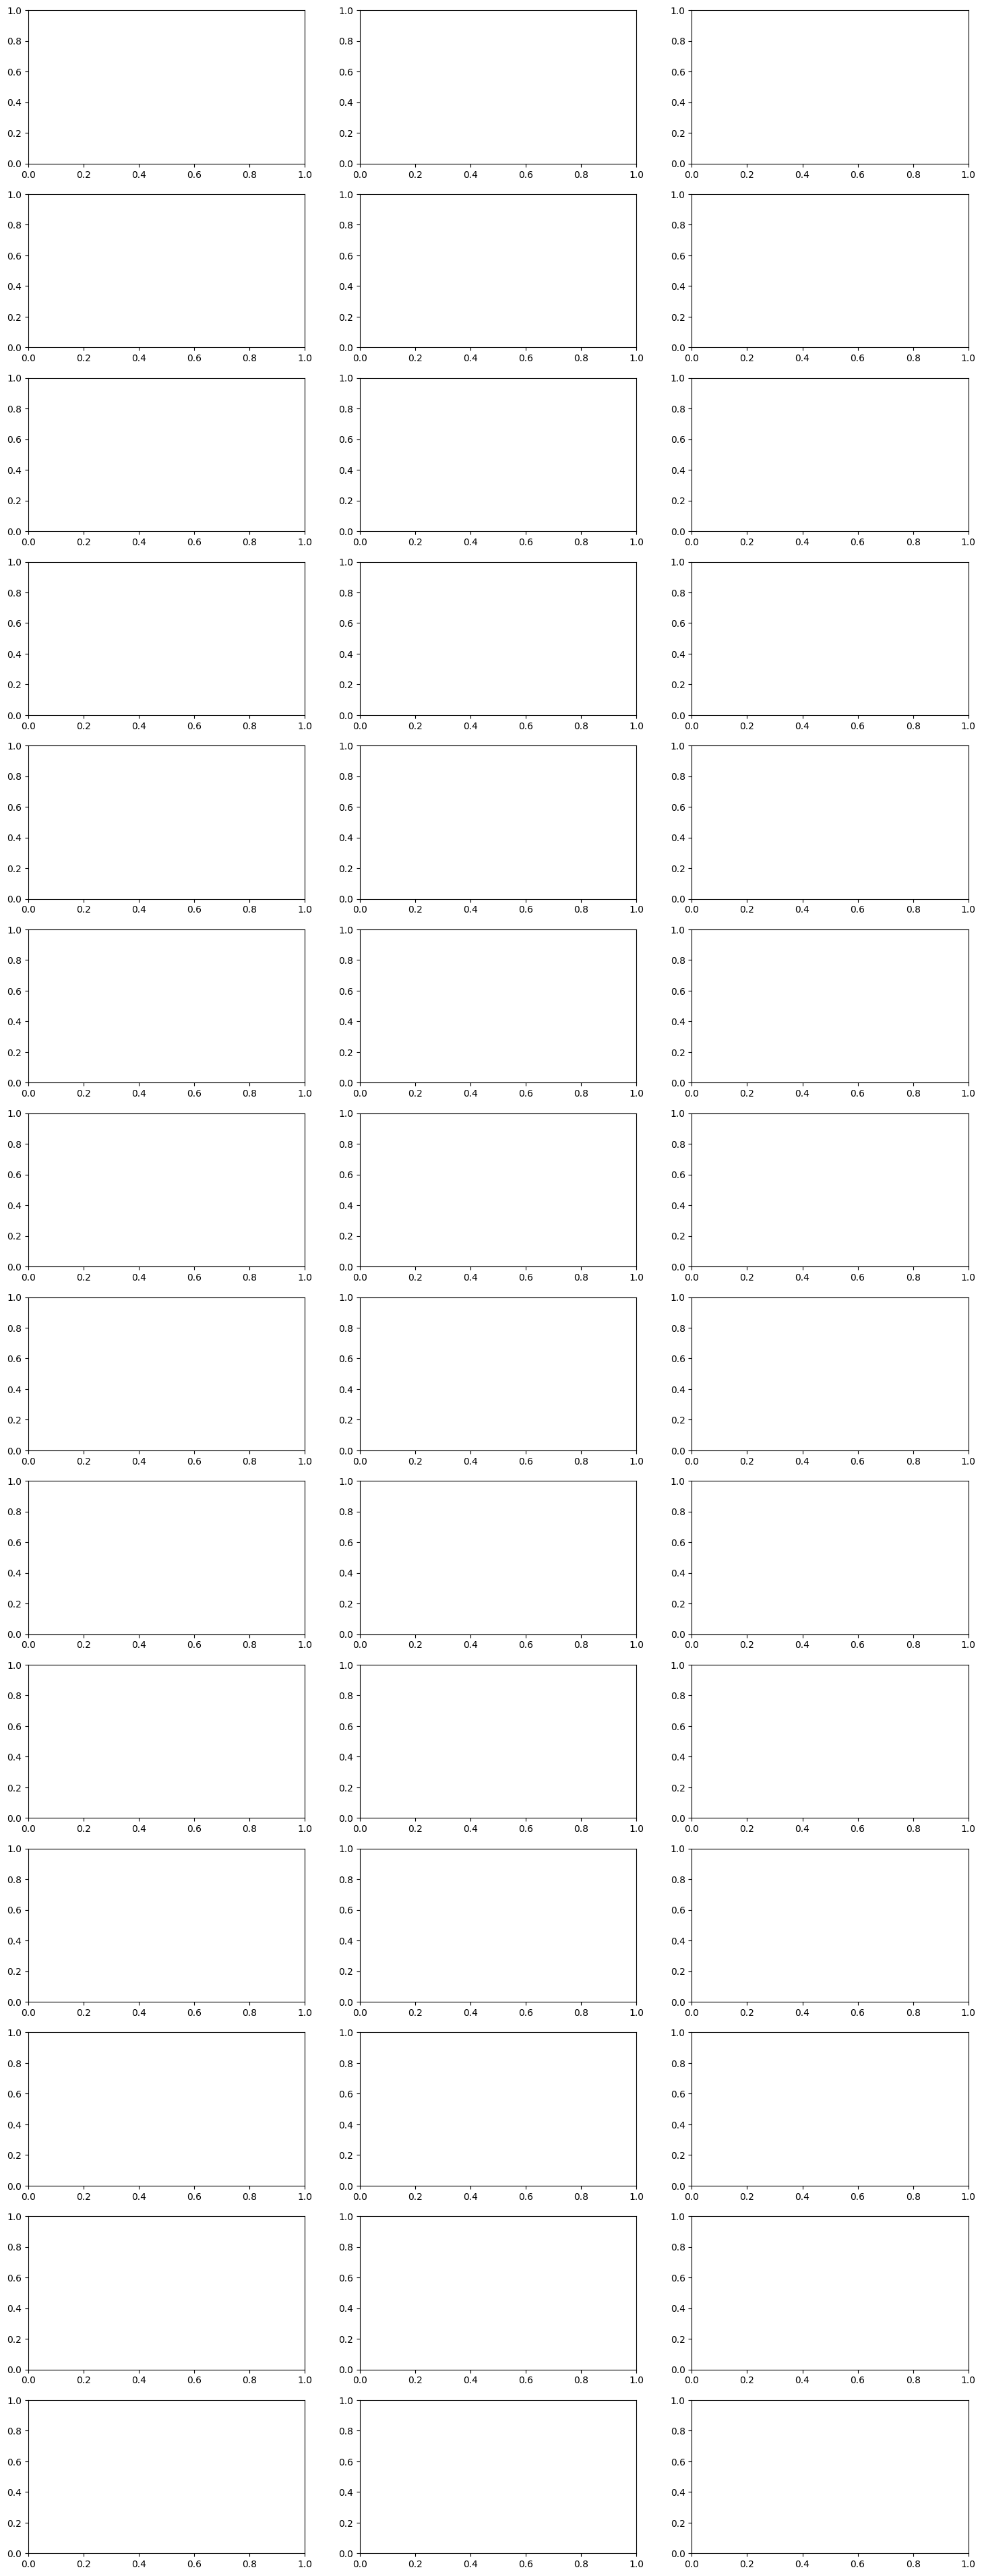

In [5]:
gradcam     = GradCAM(model, target_layer)
gradcam_pp  = GradCAMPlusPlus(model, target_layer)

fig, axes = plt.subplots(len(samples), 3, figsize=(18, len(samples) * 3.5))
if len(samples) == 1:
    axes = axes[np.newaxis, :]

for i, s in enumerate(samples):
    img_np = np.array(s['pil_image'].resize((380, 285)))

    # GradCAM
    cam  = gradcam.generate(s['tensor'], class_idx=s['true_label'])
    over = gradcam.overlay_on_image(img_np, cam)

    # GradCAM++
    cam_pp  = gradcam_pp.generate(s['tensor'], class_idx=s['true_label'])
    over_pp = gradcam_pp.overlay_on_image(img_np, cam_pp)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title(f'{s["class"]} — Original', fontsize=9)

    axes[i,1].imshow(over)
    axes[i,1].set_title('GradCAM', fontsize=9)

    axes[i,2].imshow(over_pp)
    axes[i,2].set_title('GradCAM++', fontsize=9)

    for ax in axes[i]:
        ax.axis('off')

plt.suptitle('GradCAM / GradCAM++ Explanations per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xai/gradcam_all_classes.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved → ../results/xai/gradcam_all_classes.png')

## 5. Integrated Gradients

In [ ]:
ig = IntegratedGradients(model)

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(16, len(CLASS_NAMES) * 3.5))

unique_samples = [next(s for s in samples if s['class'] == cls) for cls in CLASS_NAMES]

for i, s in enumerate(unique_samples):
    img_np = np.array(s['pil_image'].resize((380, 285)))

    # IG attribution
    attr = ig.generate(s['tensor'], class_idx=s['true_label'], n_steps=50)
    # Sum over channels → absolute value → normalise
    attr_map = np.abs(attr).sum(axis=0)
    attr_map = (attr_map - attr_map.min()) / (attr_map.max() + 1e-8)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title(f'{s["class"]} — Original', fontsize=9)

    axes[i,1].imshow(attr_map, cmap='hot')
    axes[i,1].set_title('IG Attribution (absolute)', fontsize=9)

    # Overlay
    overlay = img_np.copy().astype(float)
    heat = plt.cm.hot(attr_map)[:,:,:3]
    overlay = 0.6 * overlay/255 + 0.4 * heat
    overlay = np.clip(overlay, 0, 1)
    axes[i,2].imshow(overlay)
    axes[i,2].set_title('IG Overlay', fontsize=9)

    for ax in axes[i]:
        ax.axis('off')

plt.suptitle('Integrated Gradients — Class-wise Attribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xai/integrated_gradients.png', bbox_inches='tight', dpi=100)
plt.show()

## 6. Model Calibration Analysis

In [ ]:
from src.train import TemperatureScaler
from sklearn.calibration import calibration_curve

_, val_loader, _, _ = build_dataloaders(
    data_root=DATA_ROOT, image_size=380, batch_size=32,
)

ts = TemperatureScaler()
ts.fit(model, val_loader, DEVICE)
print(f'Optimal temperature T = {ts.temperature.item():.3f}')
print('T > 1 → model is over-confident (softens probabilities)')
print('T < 1 → model is under-confident (sharpens probabilities)')

In [ ]:
import torch.nn.functional as F

def get_probs(loader):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            imgs, targets = batch[0].to(DEVICE), batch[1]
            logits = model(imgs)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_targets.extend(targets.numpy())
    return np.concatenate(all_probs), np.array(all_targets)

probs_uncal, targets_val = get_probs(val_loader)

# Temperature-scaled probs
_, val_loader2, _, _ = build_dataloaders(DATA_ROOT, image_size=380, batch_size=32)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confidence histogram
max_probs = probs_uncal.max(axis=1)
axes[0].hist(max_probs, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(max_probs.mean(), color='red', linestyle='--', label=f'mean={max_probs.mean():.3f}')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].set_xlabel('Max Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Reliability diagram (binary: correct class vs. confidence)
y_bin = (probs_uncal.argmax(axis=1) == targets_val).astype(int)
frac_pos, mean_pred = calibration_curve(y_bin, max_probs, n_bins=10)
axes[1].plot(mean_pred, frac_pos, 'bs-', label='Uncalibrated')
axes[1].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[1].set_title('Reliability Diagram')
axes[1].set_xlabel('Mean Predicted Confidence')
axes[1].set_ylabel('Fraction Correct')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/xai/calibration.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Failure Case Analysis

Understanding WHERE the model fails is as important as measuring accuracy.

In [ ]:
from src.train import evaluate as eval_model
from src.losses import build_loss
import pandas as pd

_, _, test_loader, test_df = build_dataloaders(
    DATA_ROOT, image_size=380, batch_size=32,
)
criterion_test = build_loss('label_smoothing', class_weights=None)

test_out = eval_model(model, test_loader, criterion_test, DEVICE)
preds   = test_out['all_preds']
targets = test_out['all_targets']
probs   = test_out['all_probs']

# Find misclassified samples with HIGH confidence — most dangerous errors
conf       = probs.max(axis=1)
correct    = preds == targets
danger_idx = np.where((~correct) & (conf > 0.9))[0]

print(f'Total test samples:           {len(targets)}')
print(f'Misclassified:                {(~correct).sum()} ({(~correct).mean()*100:.1f}%)')
print(f'High-conf misclassified (>90%): {len(danger_idx)}')
print()

# Confusion analysis
err_df = pd.DataFrame({
    'true':    [CLASS_NAMES[t] for t in targets[~correct]],
    'pred':    [CLASS_NAMES[p] for p in preds[~correct]],
    'conf':    conf[~correct]
})
print('Most common error pairs:')
print(err_df.groupby(['true','pred']).size().sort_values(ascending=False).head(10))

## 8. Clinical Validation Summary

### Sensitivity Analysis (High Clinical Priority)

The most critical metric for skin lesion detection is **melanoma sensitivity (recall)**.  
A missed melanoma is far more dangerous than a false positive.

| Diagnosis | Clinical Risk | Target Recall | Acceptable FP Rate |
|-----------|--------------|---------------|--------------------|
| mel (melanoma) | Very High | ≥ 0.90 | High (up to 30%) |
| bcc (BCC) | High | ≥ 0.85 | Moderate |
| akiec | Moderate | ≥ 0.80 | Moderate |
| Others | Low | ≥ 0.75 | Low |

### XAI Validation Checklist
- [ ] GradCAM focuses on lesion body, not background skin
- [ ] GradCAM does NOT focus on hair artefacts
- [ ] For melanoma: attention on border irregularity and colour heterogeneity
- [ ] Integrated Gradients shows smooth attribution (not noisy → model is stable)
- [ ] Model is well-calibrated (reliability diagram close to diagonal)